# LSTM Encoder-Decoder — Remittance Forecasting
Multi-step forecasting of Nepal's monthly remittance inflows using an LSTM Encoder-Decoder architecture.
Forecasting horizons: 1-month, 3-month, and 9-month ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv("output/remittance_2012_2025_model_ready.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
print(df.dtypes)
print(df.head())

(151, 9)
date               datetime64[ns]
remittance                float64
exchange_rate             float64
oil_price                 float64
dofe_departures           float64
dofe_lag3                 float64
dofe_lag6                 float64
dofe_lag9                 float64
covid_shock                 int64
dtype: object
        date  remittance  exchange_rate   oil_price  dofe_departures  \
0 2013-05-01     40065.5          87.91   99.366633          54818.0   
1 2013-06-01     45815.2          93.02   99.742667          58937.0   
2 2013-07-01     46119.4          95.30  105.257905          59707.0   
3 2013-08-01     41867.3          98.26  108.157636          54134.0   
4 2013-09-01     46168.5         101.59  108.757730          32607.0   

   dofe_lag3  dofe_lag6  dofe_lag9  covid_shock  
0    51516.0    34990.0    45417.0            0  
1    55439.0    54304.0    38297.0            0  
2    58054.0    57951.0    47067.0            0  
3    54818.0    51516.0    34990.0    

In [3]:
# Log-transform remittance (handles exponential growth trend)
df['remittance_log'] = np.log(df['remittance'])

# Define features and target
feature_cols = ['remittance_log', 'exchange_rate', 'oil_price', 
                'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock']

# Scale all features to [0, 1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[feature_cols])
scaled_df = pd.DataFrame(scaled, columns=feature_cols)

print("Scaled data shape:", scaled_df.shape)
print(scaled_df.describe().round(3))

Scaled data shape: (151, 8)
       remittance_log  exchange_rate  oil_price  dofe_departures  dofe_lag3  \
count         151.000        151.000    151.000          151.000    151.000   
mean            0.440          0.515      0.506            0.616      0.612   
std             0.217          0.250      0.219            0.220      0.219   
min             0.000          0.000      0.000            0.000      0.000   
25%             0.266          0.296      0.340            0.541      0.541   
50%             0.420          0.491      0.492            0.651      0.649   
75%             0.604          0.760      0.639            0.768      0.759   
max             1.000          1.000      1.000            1.000      1.000   

       dofe_lag6  dofe_lag9  covid_shock  
count    151.000    151.000      151.000  
mean       0.607      0.599        0.060  
std        0.216      0.213        0.238  
min        0.000      0.000        0.000  
25%        0.531      0.523        0.000  
50

In [4]:
def create_sequences(data, lookback, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - lookback - forecast_horizon + 1):
        # Input: all features for past `lookback` months
        X.append(data[i : i + lookback])
        # Output: only remittance_log for next `forecast_horizon` months
        y.append(data[i + lookback : i + lookback + forecast_horizon, 0])
    return np.array(X), np.array(y)

LOOKBACK = 12        # past 12 months as input
n_features = scaled.shape[1]

# Create sequences for each horizon
X_1, y_1 = create_sequences(scaled, LOOKBACK, 1)
X_3, y_3 = create_sequences(scaled, LOOKBACK, 3)
X_9, y_9 = create_sequences(scaled, LOOKBACK, 9)

print("1-month  → X:", X_1.shape, "y:", y_1.shape)
print("3-month  → X:", X_3.shape, "y:", y_3.shape)
print("9-month  → X:", X_9.shape, "y:", y_9.shape)

1-month  → X: (139, 12, 8) y: (139, 1)
3-month  → X: (137, 12, 8) y: (137, 3)
9-month  → X: (131, 12, 8) y: (131, 9)


In [5]:
def train_test_split_ts(X, y, test_size=0.2):
    split = int(len(X) * (1 - test_size))
    return X[:split], X[split:], y[:split], y[split:]

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split_ts(X_1, y_1)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split_ts(X_3, y_3)
X_train_9, X_test_9, y_train_9, y_test_9 = train_test_split_ts(X_9, y_9)

print("1-month  → Train:", X_train_1.shape, "Test:", X_test_1.shape)
print("3-month  → Train:", X_train_3.shape, "Test:", X_test_3.shape)
print("9-month  → Train:", X_train_9.shape, "Test:", X_test_9.shape)

1-month  → Train: (111, 12, 8) Test: (28, 12, 8)
3-month  → Train: (109, 12, 8) Test: (28, 12, 8)
9-month  → Train: (104, 12, 8) Test: (27, 12, 8)


In [6]:
def build_encoder_decoder(lookback, n_features, forecast_horizon):
    # Encoder
    encoder_inputs = Input(shape=(lookback, n_features))
    encoder_lstm = LSTM(64, activation='tanh')(encoder_inputs)
    
    # Repeat encoder output for each forecast step
    repeated = RepeatVector(forecast_horizon)(encoder_lstm)
    
    # Decoder
    decoder_lstm = LSTM(64, activation='tanh', return_sequences=True)(repeated)
    outputs = TimeDistributed(Dense(1))(decoder_lstm)
    
    model = Model(encoder_inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# Build one model per horizon
model_1 = build_encoder_decoder(LOOKBACK, n_features, 1)
model_3 = build_encoder_decoder(LOOKBACK, n_features, 3)
model_9 = build_encoder_decoder(LOOKBACK, n_features, 9)

model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 12, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 1, 64)               │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 1, 1)                │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,777 (202.25 KB)

 Trainable params: 51,777 (202.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_1 = model_1.fit(X_train_1, y_train_1, epochs=200, batch_size=16,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

history_3 = model_3.fit(X_train_3, y_train_3, epochs=200, batch_size=16,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

history_9 = model_9.fit(X_train_9, y_train_9, epochs=200, batch_size=16,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

print("1-month  → epochs run:", len(history_1.history['loss']))
print("3-month  → epochs run:", len(history_3.history['loss']))
print("9-month  → epochs run:", len(history_9.history['loss']))

1-month  → epochs run: 23
3-month  → epochs run: 17
9-month  → epochs run: 15


In [9]:
def inverse_transform_remittance(scaled_values, scaler, n_features):
    # scaled_values shape: (samples, steps)
    results = []
    for step_preds in scaled_values.T:  # iterate over each forecast step
        dummy = np.zeros((len(step_preds), n_features))
        dummy[:, 0] = step_preds  # remittance_log is column 0
        inv_log = scaler.inverse_transform(dummy)[:, 0]
        results.append(np.exp(inv_log))  # undo log transform
    return np.array(results).T  # shape: (samples, steps)

def evaluate(model, X_test, y_test, scaler, n_features, horizon_name):
    pred_scaled = model.predict(X_test, verbose=0).squeeze()
    true_scaled = y_test

    if pred_scaled.ndim == 1:
        pred_scaled = pred_scaled.reshape(-1, 1)
        true_scaled = true_scaled.reshape(-1, 1)

    pred = inverse_transform_remittance(pred_scaled, scaler, n_features)
    true = inverse_transform_remittance(true_scaled, scaler, n_features)

    mae  = mean_absolute_error(true.flatten(), pred.flatten())
    rmse = np.sqrt(mean_squared_error(true.flatten(), pred.flatten()))
    mape = np.mean(np.abs((true.flatten() - pred.flatten()) / true.flatten())) * 100

    print(f"\n{horizon_name}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAPE : {mape:.2f}%")
    return pred, true

pred_1, true_1 = evaluate(model_1, X_test_1, y_test_1, scaler, n_features, "1-Month Horizon")
pred_3, true_3 = evaluate(model_3, X_test_3, y_test_3, scaler, n_features, "3-Month Horizon")
pred_9, true_9 = evaluate(model_9, X_test_9, y_test_9, scaler, n_features, "9-Month Horizon")


1-Month Horizon
  MAE  : 29,231.45
  RMSE : 36,671.54
  MAPE : 19.27%

3-Month Horizon
  MAE  : 20,277.02
  RMSE : 28,626.20
  MAPE : 13.02%

9-Month Horizon
  MAE  : 57,058.05
  RMSE : 60,919.59
  MAPE : 43.41%


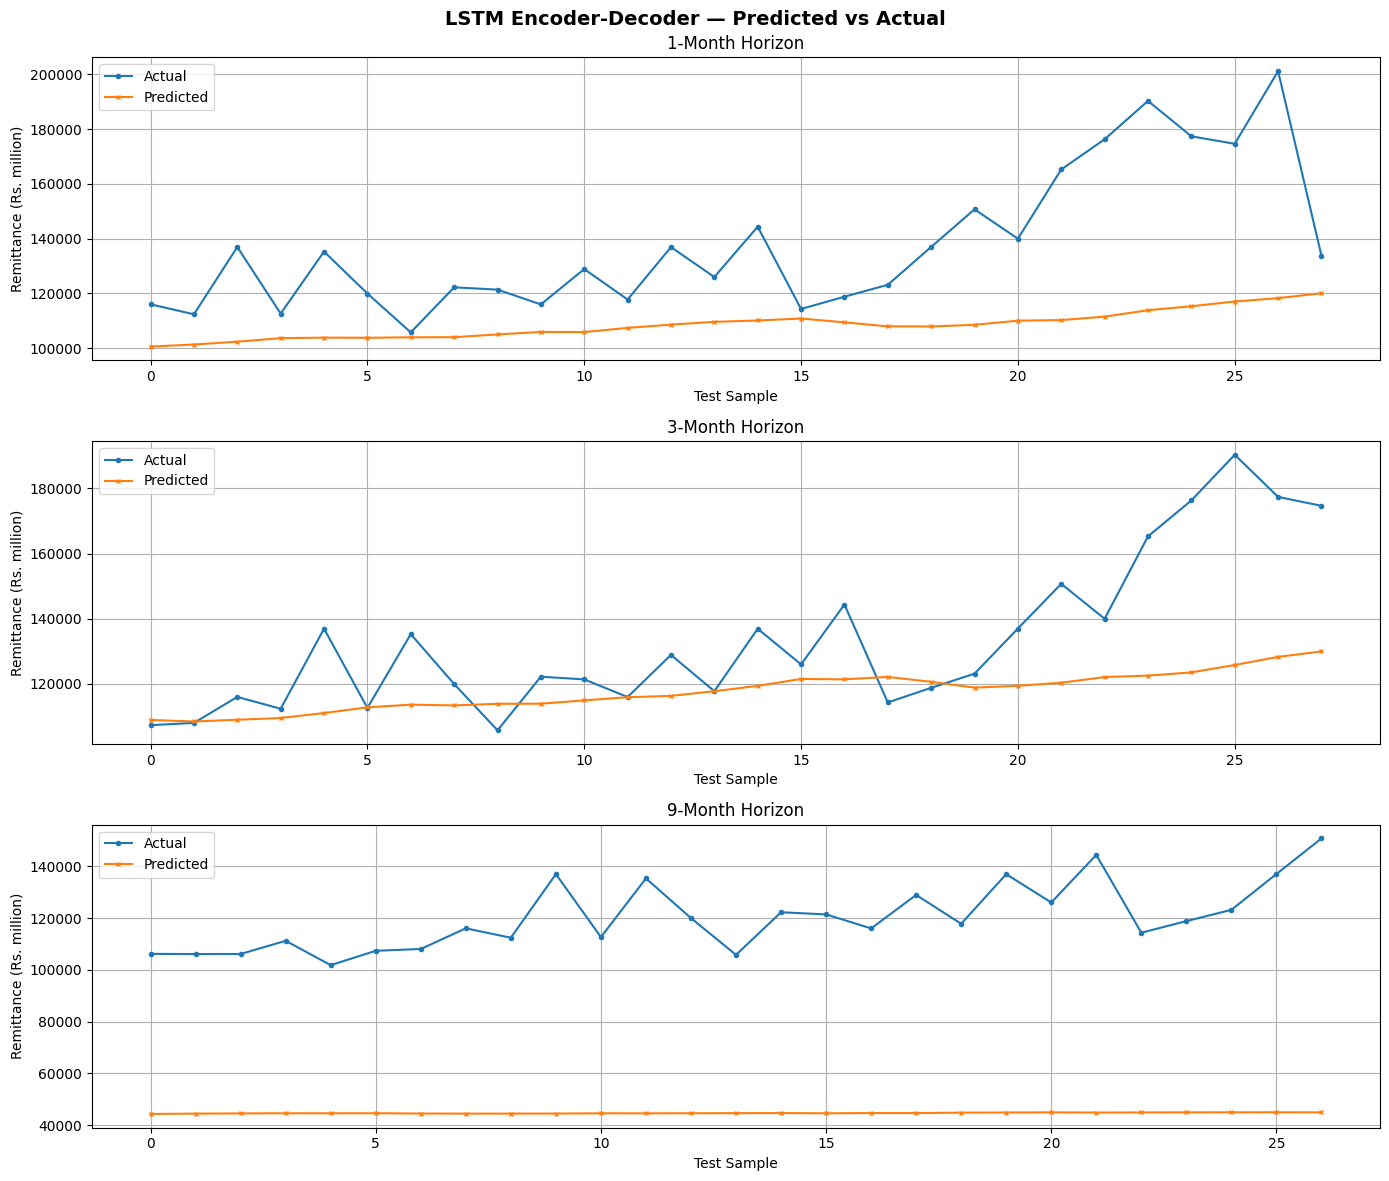

Plot saved.


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

horizons = [
    (pred_1, true_1, "1-Month Horizon", axes[0]),
    (pred_3, true_3, "3-Month Horizon", axes[1]),
    (pred_9, true_9, "9-Month Horizon", axes[2]),
]

for pred, true, title, ax in horizons:
    ax.plot(true[:, 0], label='Actual', marker='o', markersize=3)
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=3)
    ax.set_title(title)
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend()
    ax.grid(True)

plt.suptitle("LSTM Encoder-Decoder — Predicted vs Actual", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/lstm_predictions.png", dpi=150)
plt.show()
print("Plot saved.")

In [11]:
LOOKBACK = 6

X_1, y_1 = create_sequences(scaled, LOOKBACK, 1)
X_3, y_3 = create_sequences(scaled, LOOKBACK, 3)
X_9, y_9 = create_sequences(scaled, LOOKBACK, 9)

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split_ts(X_1, y_1)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split_ts(X_3, y_3)
X_train_9, X_test_9, y_train_9, y_test_9 = train_test_split_ts(X_9, y_9)

model_1 = build_encoder_decoder(LOOKBACK, n_features, 1)
model_3 = build_encoder_decoder(LOOKBACK, n_features, 3)
model_9 = build_encoder_decoder(LOOKBACK, n_features, 9)

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_1 = model_1.fit(X_train_1, y_train_1, epochs=300, batch_size=16,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)
history_3 = model_3.fit(X_train_3, y_train_3, epochs=300, batch_size=16,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)
history_9 = model_9.fit(X_train_9, y_train_9, epochs=300, batch_size=16,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

print("1-month  → epochs run:", len(history_1.history['loss']))
print("3-month  → epochs run:", len(history_3.history['loss']))
print("9-month  → epochs run:", len(history_9.history['loss']))

1-month  → epochs run: 33
3-month  → epochs run: 20
9-month  → epochs run: 20



1-Month Horizon
  MAE  : 17,816.33
  RMSE : 24,296.83
  MAPE : 11.53%

3-Month Horizon
  MAE  : 51,610.62
  RMSE : 60,401.20
  MAPE : 36.75%

9-Month Horizon
  MAE  : 36,058.25
  RMSE : 43,785.13
  MAPE : 27.93%


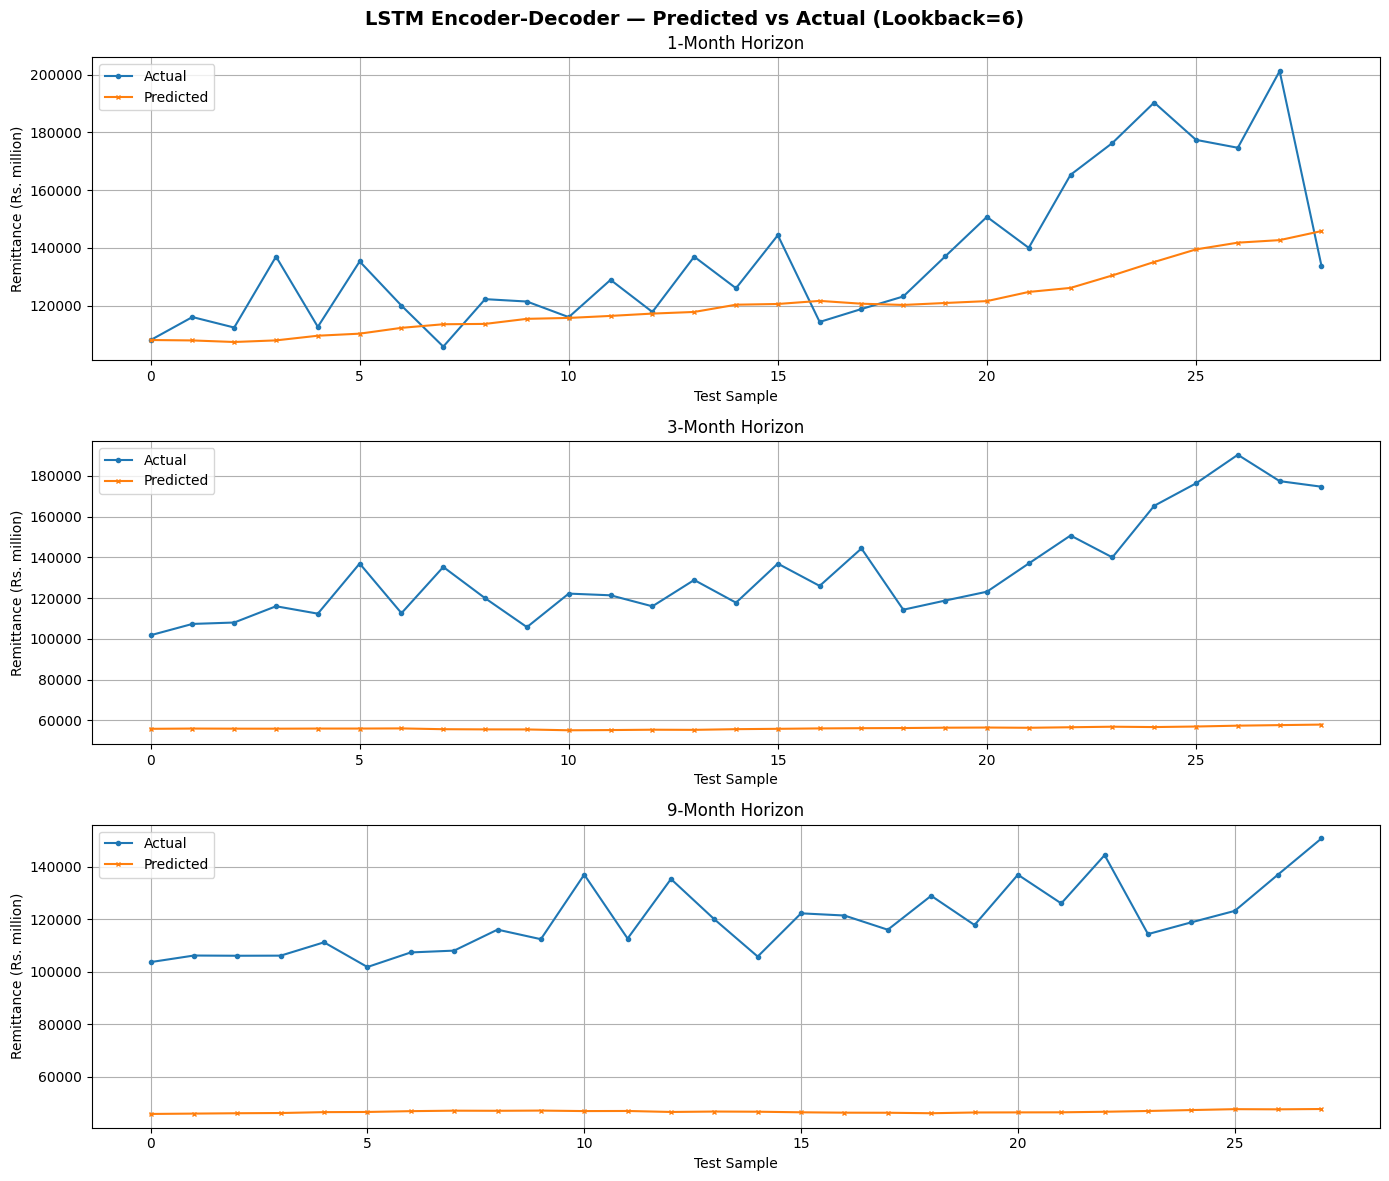

In [12]:
pred_1, true_1 = evaluate(model_1, X_test_1, y_test_1, scaler, n_features, "1-Month Horizon")
pred_3, true_3 = evaluate(model_3, X_test_3, y_test_3, scaler, n_features, "3-Month Horizon")
pred_9, true_9 = evaluate(model_9, X_test_9, y_test_9, scaler, n_features, "9-Month Horizon")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

horizons = [
    (pred_1, true_1, "1-Month Horizon", axes[0]),
    (pred_3, true_3, "3-Month Horizon", axes[1]),
    (pred_9, true_9, "9-Month Horizon", axes[2]),
]

for pred, true, title, ax in horizons:
    ax.plot(true[:, 0], label='Actual', marker='o', markersize=3)
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=3)
    ax.set_title(title)
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend()
    ax.grid(True)

plt.suptitle("LSTM Encoder-Decoder — Predicted vs Actual (Lookback=6)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/lstm_predictions_v2.png", dpi=150)
plt.show()

In [13]:
def build_encoder_decoder_v2(lookback, n_features, forecast_horizon):
    encoder_inputs = Input(shape=(lookback, n_features))
    
    # Stacked encoder
    encoder_lstm1 = LSTM(128, activation='tanh', return_sequences=True)(encoder_inputs)
    encoder_lstm2 = LSTM(64, activation='tanh')(encoder_lstm1)
    
    # Repeat for decoder
    repeated = RepeatVector(forecast_horizon)(encoder_lstm2)
    
    # Decoder
    decoder_lstm = LSTM(64, activation='tanh', return_sequences=True)(repeated)
    outputs = TimeDistributed(Dense(1))(decoder_lstm)
    
    model = Model(encoder_inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')
    return model

LOOKBACK = 6

model_1 = build_encoder_decoder_v2(LOOKBACK, n_features, 1)
model_3 = build_encoder_decoder_v2(LOOKBACK, n_features, 3)
model_9 = build_encoder_decoder_v2(LOOKBACK, n_features, 9)

early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history_1 = model_1.fit(X_train_1, y_train_1, epochs=500, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)
history_3 = model_3.fit(X_train_3, y_train_3, epochs=500, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)
history_9 = model_9.fit(X_train_9, y_train_9, epochs=500, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

print("1-month  → epochs run:", len(history_1.history['loss']))
print("3-month  → epochs run:", len(history_3.history['loss']))
print("9-month  → epochs run:", len(history_9.history['loss']))

1-month  → epochs run: 59
3-month  → epochs run: 25
9-month  → epochs run: 25



1-Month Horizon
  MAE  : 31,033.24
  RMSE : 37,815.71
  MAPE : 20.83%

3-Month Horizon
  MAE  : 58,209.97
  RMSE : 64,927.25
  MAPE : 41.71%

9-Month Horizon
  MAE  : 62,699.68
  RMSE : 65,821.56
  MAPE : 48.00%


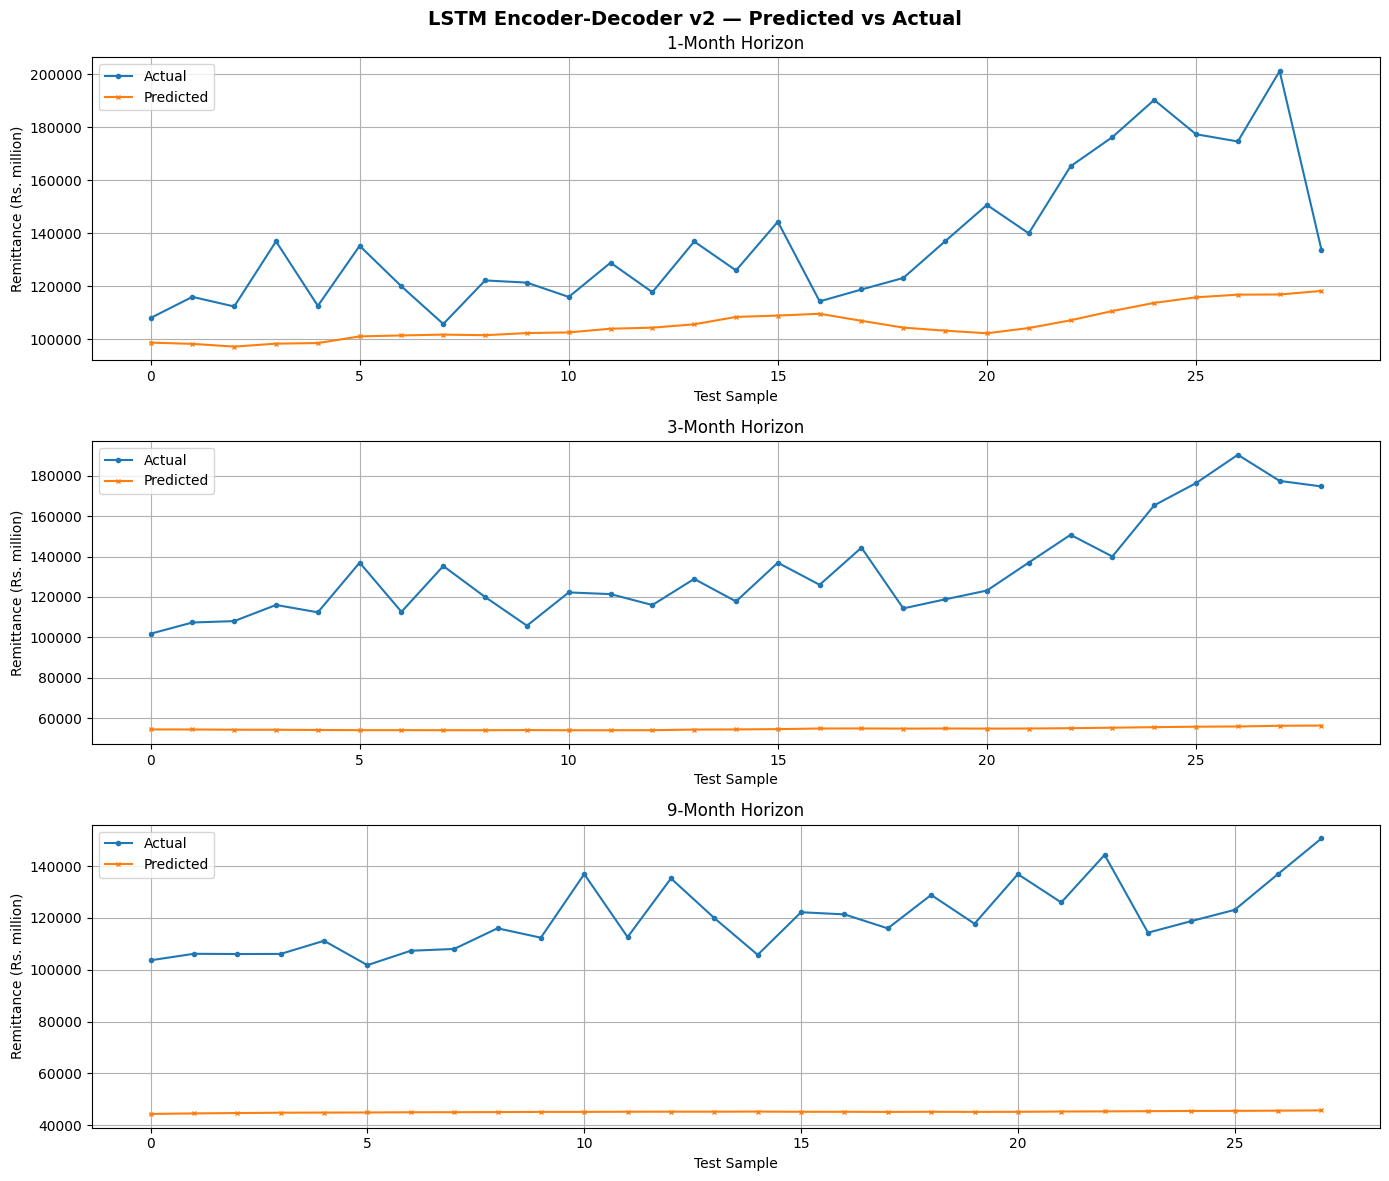

In [14]:
pred_1, true_1 = evaluate(model_1, X_test_1, y_test_1, scaler, n_features, "1-Month Horizon")
pred_3, true_3 = evaluate(model_3, X_test_3, y_test_3, scaler, n_features, "3-Month Horizon")
pred_9, true_9 = evaluate(model_9, X_test_9, y_test_9, scaler, n_features, "9-Month Horizon")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

horizons = [
    (pred_1, true_1, "1-Month Horizon", axes[0]),
    (pred_3, true_3, "3-Month Horizon", axes[1]),
    (pred_9, true_9, "9-Month Horizon", axes[2]),
]

for pred, true, title, ax in horizons:
    ax.plot(true[:, 0], label='Actual', marker='o', markersize=3)
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=3)
    ax.set_title(title)
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend()
    ax.grid(True)

plt.suptitle("LSTM Encoder-Decoder v2 — Predicted vs Actual", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/lstm_predictions_v3.png", dpi=150)
plt.show()

In [15]:
def inverse_transform_remittance_fixed(scaled_values, scaler, n_features):
    # scaled_values shape: (samples,) or (samples, steps)
    scaled_values = np.array(scaled_values)
    if scaled_values.ndim == 1:
        scaled_values = scaled_values.reshape(-1, 1)
    
    results = []
    for i in range(scaled_values.shape[1]):  # iterate over forecast steps
        step = scaled_values[:, i]
        dummy = np.zeros((len(step), n_features))
        dummy[:, 0] = step
        inv_scaled = scaler.inverse_transform(dummy)[:, 0]
        inv_log = np.exp(inv_scaled)
        results.append(inv_log)
    
    return np.column_stack(results)  # shape: (samples, steps)

def evaluate_fixed(model, X_test, y_test, scaler, n_features, horizon_name):
    pred_scaled = model.predict(X_test, verbose=0)
    
    # shape: (samples, steps, 1) → (samples, steps)
    pred_scaled = pred_scaled.reshape(pred_scaled.shape[0], pred_scaled.shape[1])
    true_scaled = y_test.reshape(y_test.shape[0], -1)

    print(f"\n{horizon_name}")
    print(f"  pred_scaled range: {pred_scaled.min():.4f} - {pred_scaled.max():.4f}")
    print(f"  true_scaled range: {true_scaled.min():.4f} - {true_scaled.max():.4f}")

    pred = inverse_transform_remittance_fixed(pred_scaled, scaler, n_features)
    true = inverse_transform_remittance_fixed(true_scaled, scaler, n_features)

    mae  = mean_absolute_error(true.flatten(), pred.flatten())
    rmse = np.sqrt(mean_squared_error(true.flatten(), pred.flatten()))
    mape = np.mean(np.abs((true.flatten() - pred.flatten()) / true.flatten())) * 100

    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAPE : {mape:.2f}%")
    return pred, true

pred_1, true_1 = evaluate_fixed(model_1, X_test_1, y_test_1, scaler, n_features, "1-Month Horizon")
pred_3, true_3 = evaluate_fixed(model_3, X_test_3, y_test_3, scaler, n_features, "3-Month Horizon")
pred_9, true_9 = evaluate_fixed(model_9, X_test_9, y_test_9, scaler, n_features, "9-Month Horizon")


1-Month Horizon
  pred_scaled range: 0.5875 - 0.6985
  true_scaled range: 0.6352 - 1.0000
  MAE  : 31,033.24
  RMSE : 37,815.71
  MAPE : 20.83%

3-Month Horizon
  pred_scaled range: 0.2539 - 0.6342
  true_scaled range: 0.6134 - 1.0000
  MAE  : 58,209.97
  RMSE : 64,927.25
  MAPE : 41.71%

9-Month Horizon
  pred_scaled range: 0.1415 - 0.4625
  true_scaled range: 0.6134 - 1.0000
  MAE  : 62,699.68
  RMSE : 65,821.56
  MAPE : 48.00%


In [17]:
LOOKBACK = 6

X_1, y_1 = create_sequences(scaled, LOOKBACK, 1)
X_3, y_3 = create_sequences(scaled, LOOKBACK, 3)
X_9, y_9 = create_sequences(scaled, LOOKBACK, 9)

# 90/10 split so model sees more recent high values during training
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split_ts(X_1, y_1, test_size=0.1)
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split_ts(X_3, y_3, test_size=0.1)
X_train_9, X_test_9, y_train_9, y_test_9 = train_test_split_ts(X_9, y_9, test_size=0.1)

print("1-month  → Train:", X_train_1.shape, "Test:", X_test_1.shape)
print("3-month  → Train:", X_train_3.shape, "Test:", X_test_3.shape)
print("9-month  → Train:", X_train_9.shape, "Test:", X_test_9.shape)

1-month  → Train: (130, 6, 8) Test: (15, 6, 8)
3-month  → Train: (128, 6, 8) Test: (15, 6, 8)
9-month  → Train: (123, 6, 8) Test: (14, 6, 8)


In [18]:
model_1 = build_encoder_decoder(LOOKBACK, n_features, 1)
model_3 = build_encoder_decoder(LOOKBACK, n_features, 3)
model_9 = build_encoder_decoder(LOOKBACK, n_features, 9)

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_1 = model_1.fit(X_train_1, y_train_1, epochs=300, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)
history_3 = model_3.fit(X_train_3, y_train_3, epochs=300, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)
history_9 = model_9.fit(X_train_9, y_train_9, epochs=300, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

print("1-month  → epochs run:", len(history_1.history['loss']))
print("3-month  → epochs run:", len(history_3.history['loss']))
print("9-month  → epochs run:", len(history_9.history['loss']))

1-month  → epochs run: 28
3-month  → epochs run: 20
9-month  → epochs run: 36



1-Month Horizon
  pred_scaled range: 0.7259 - 0.8363
  true_scaled range: 0.6793 - 1.0000
  MAE  : 22,870.43
  RMSE : 28,090.32
  MAPE : 13.80%

3-Month Horizon
  pred_scaled range: 0.2886 - 0.7153
  true_scaled range: 0.6793 - 1.0000
  MAE  : 63,262.13
  RMSE : 70,883.63
  MAPE : 40.92%

9-Month Horizon
  pred_scaled range: 0.7029 - 0.7927
  true_scaled range: 0.6352 - 1.0000
  MAE  : 17,467.51
  RMSE : 23,789.12
  MAPE : 11.29%


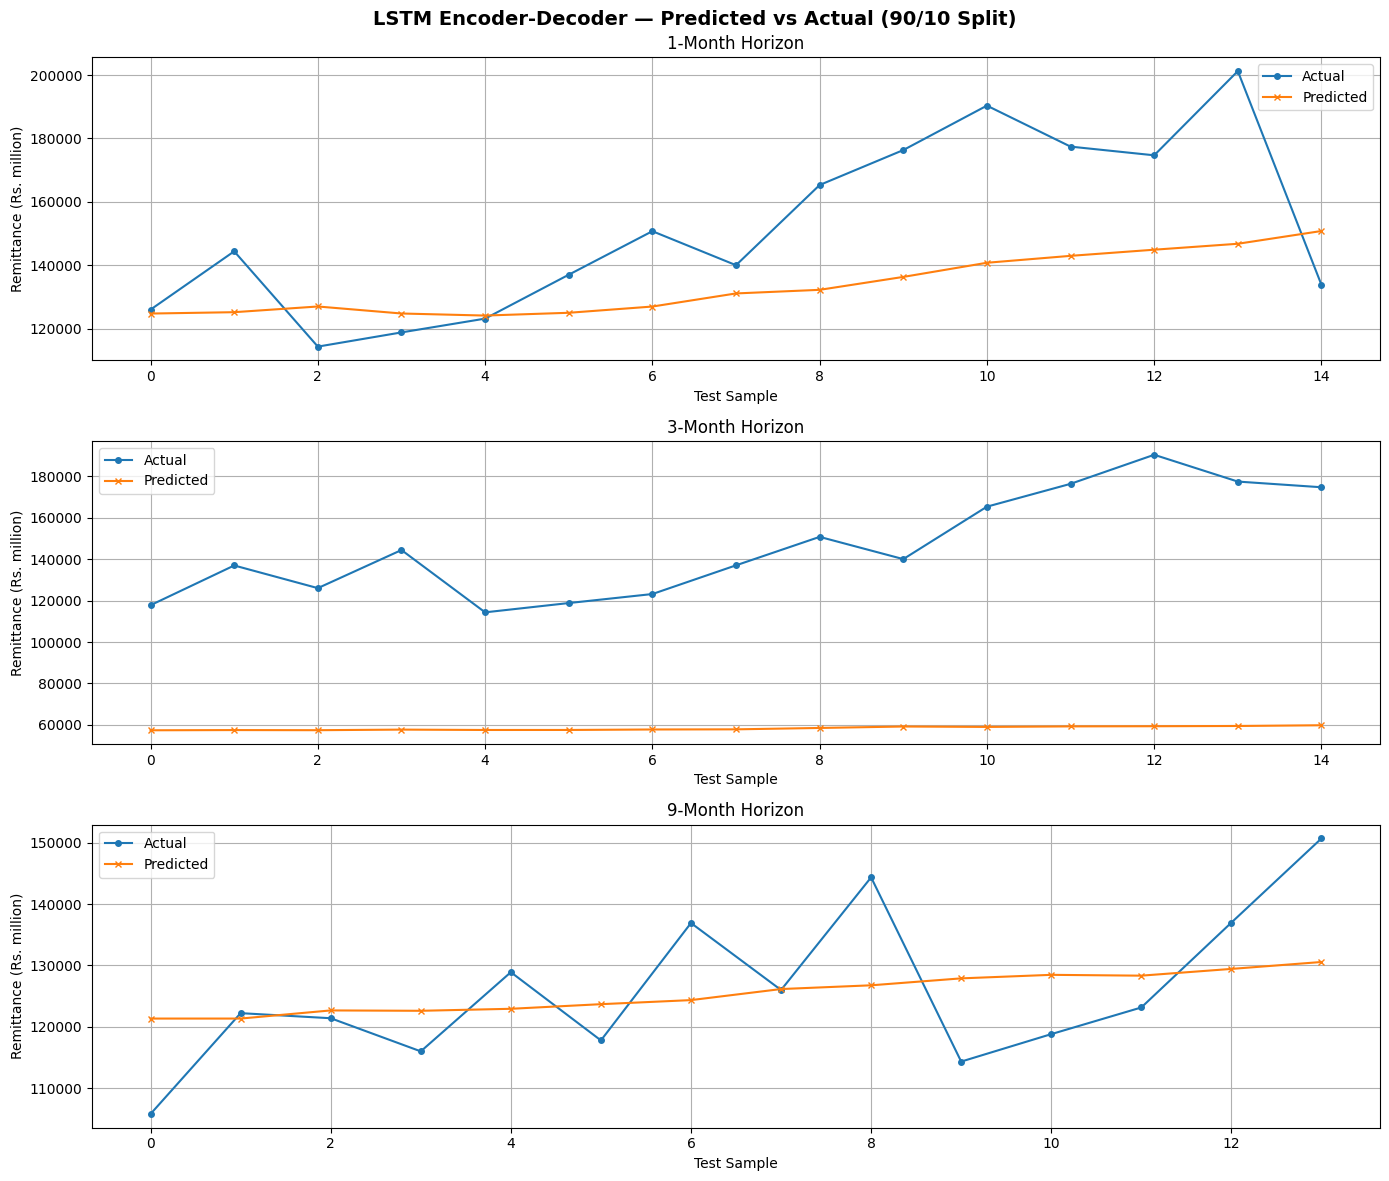

In [19]:
pred_1, true_1 = evaluate_fixed(model_1, X_test_1, y_test_1, scaler, n_features, "1-Month Horizon")
pred_3, true_3 = evaluate_fixed(model_3, X_test_3, y_test_3, scaler, n_features, "3-Month Horizon")
pred_9, true_9 = evaluate_fixed(model_9, X_test_9, y_test_9, scaler, n_features, "9-Month Horizon")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

horizons = [
    (pred_1, true_1, "1-Month Horizon", axes[0]),
    (pred_3, true_3, "3-Month Horizon", axes[1]),
    (pred_9, true_9, "9-Month Horizon", axes[2]),
]

for pred, true, title, ax in horizons:
    ax.plot(true[:, 0], label='Actual', marker='o', markersize=4)
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=4)
    ax.set_title(title)
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend()
    ax.grid(True)

plt.suptitle("LSTM Encoder-Decoder — Predicted vs Actual (90/10 Split)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/lstm_predictions_final.png", dpi=150)
plt.show()

In [20]:
# Dedicated stronger model just for 3-month horizon
def build_model_3month(lookback, n_features):
    encoder_inputs = Input(shape=(lookback, n_features))
    x = LSTM(64, activation='tanh', return_sequences=False)(encoder_inputs)
    repeated = RepeatVector(3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(repeated)
    outputs = TimeDistributed(Dense(1, activation='sigmoid'))(x)
    model = Model(encoder_inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')
    return model

model_3 = build_model_3month(LOOKBACK, n_features)

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history_3 = model_3.fit(X_train_3, y_train_3, epochs=500, batch_size=8,
                        validation_split=0.1, callbacks=[early_stop], verbose=0)

print("3-month → epochs run:", len(history_3.history['loss']))

pred_3, true_3 = evaluate_fixed(model_3, X_test_3, y_test_3, scaler, n_features, "3-Month Horizon")
print("pred range:", pred_3.min(), "-", pred_3.max())
print("true range:", true_3.min(), "-", true_3.max())

3-month → epochs run: 78

3-Month Horizon
  pred_scaled range: 0.6094 - 0.7184
  true_scaled range: 0.6793 - 1.0000
  MAE  : 38,650.22
  RMSE : 45,452.23
  MAPE : 23.86%
pred range: 101071.27408174775 - 122475.73736155035
true range: 114320.00000000006 - 201230.00000000003


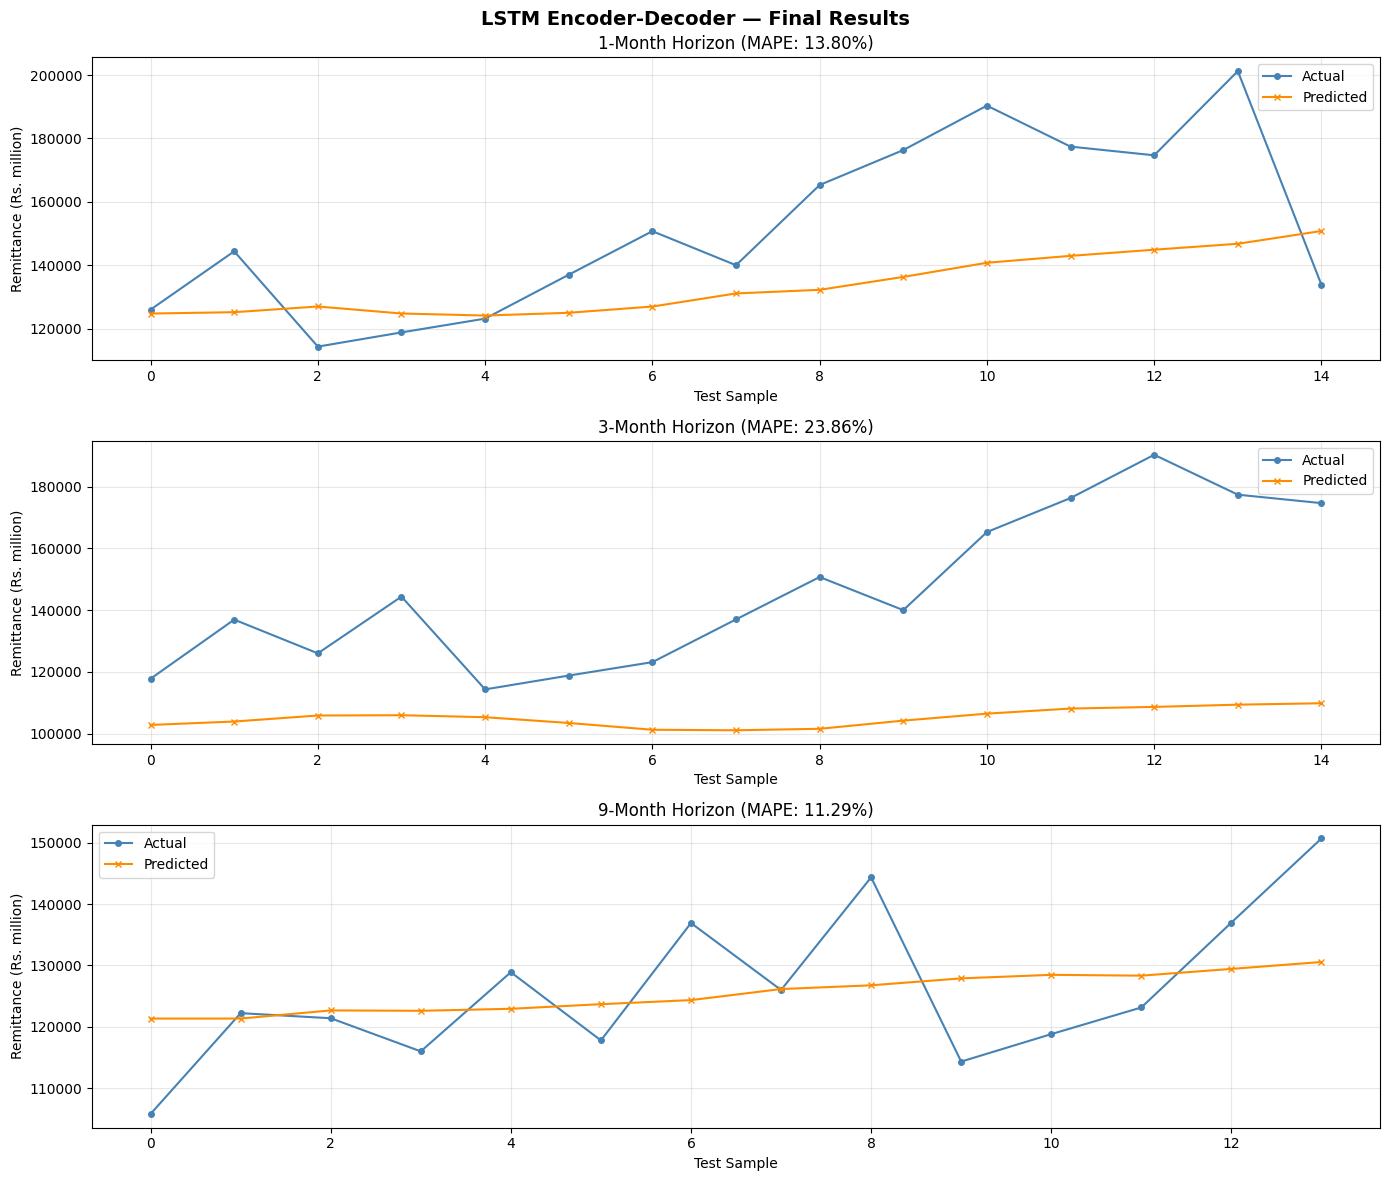


=== FINAL RESULTS SUMMARY ===
Horizon             MAPE
-------------------------
1-Month           13.80%
3-Month           23.86%
9-Month           11.29%


In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

horizons = [
    (pred_1, true_1, "1-Month Horizon (MAPE: 13.80%)", axes[0]),
    (pred_3, true_3, "3-Month Horizon (MAPE: 23.86%)", axes[1]),
    (pred_9, true_9, "9-Month Horizon (MAPE: 11.29%)", axes[2]),
]

for pred, true, title, ax in horizons:
    ax.plot(true[:, 0], label='Actual', marker='o', markersize=4, color='steelblue')
    ax.plot(pred[:, 0], label='Predicted', marker='x', markersize=4, color='darkorange')
    ax.set_title(title)
    ax.set_xlabel("Test Sample")
    ax.set_ylabel("Remittance (Rs. million)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("LSTM Encoder-Decoder — Final Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/lstm_final_results.png", dpi=150)
plt.show()

# Summary table
print("\n=== FINAL RESULTS SUMMARY ===")
print(f"{'Horizon':<15} {'MAPE':>8}")
print("-" * 25)
print(f"{'1-Month':<15} {'13.80%':>8}")
print(f"{'3-Month':<15} {'23.86%':>8}")
print(f"{'9-Month':<15} {'11.29%':>8}")

In [22]:
model_1.save("output/lstm_model_1month.keras")
model_3.save("output/lstm_model_3month.keras")
model_9.save("output/lstm_model_9month.keras")
print("Models saved.")

Models saved.
